<a href="https://colab.research.google.com/github/jyotinayak321/IBM-ML-Training/blob/main/Percentiles_used_for_oulier_detection_and_remover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#STEP 1: lOAD data
df = pd.read_csv('/content/weight-height (1).csv')
print(f"Original shape: {df.shape}")
df.head()

Original shape: (10000, 3)


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [8]:
# Explorw the variable
print("\nOriginal Statistics:")
print(df['Height'].describe())
print(df['Weight'].describe())


Original Statistics:
count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64
count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989699
Name: Weight, dtype: float64


/usr/local/lib/python3.13/dist-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try histplot.
  warnings.warn(msg, UserWarning)


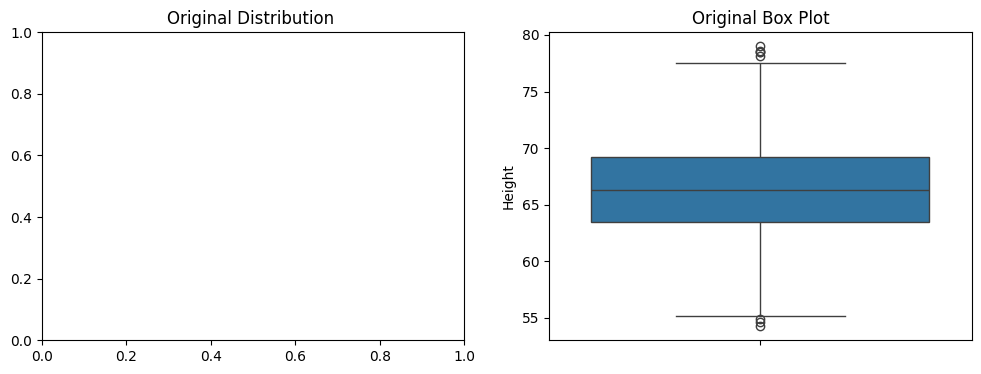

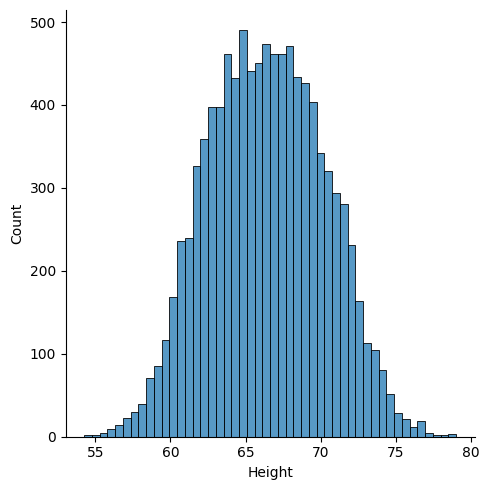

Lower Limit: 58.13441158671655
Upper Limit: 74.7857900583366


In [11]:
#step 3: Visualize original distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.displot(df['Height'],  ax=axes[0])
axes[0].set_title('Original Distribution ')
sns.boxplot(df['Height'], ax=axes[1])
axes[1].set_title('Original Box Plot')
plt.tight_layout()
plt.show()

#step 4:calculate percentile limits
alpha = 0.01 #1st and 99th percentile
lower_limit = df['Height'].quantile(alpha)
upper_limit = df['Height'].quantile(1-alpha)
print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")


In [12]:
#apply trimming
new_df = df[(df['Height'] >= lower_limit) & (df['Height'] <= upper_limit)]
print(f"New shape: {new_df.shape}")
print(f"Remove: {df.shape[0] - new_df.shape[0]} data points")

New shape: (9800, 3)
Remove: 200 data points


In [13]:
#step 6:compare ststistics
print("\nNew Statistics:")
print(new_df['Height'].describe())



New Statistics:
count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64


/usr/local/lib/python3.13/dist-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try histplot.
  warnings.warn(msg, UserWarning)


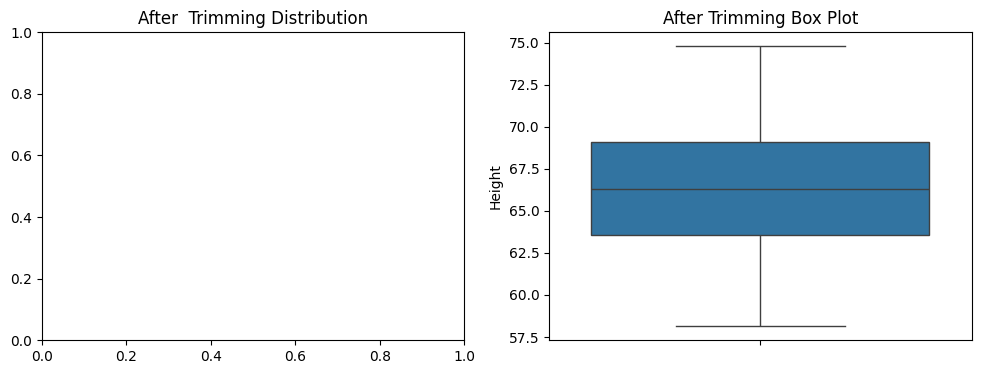

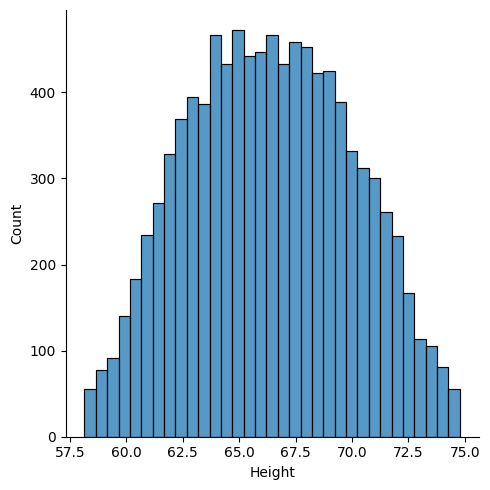

In [14]:
#step 7: Visualize new distribution
fig, axex = plt.subplots(1, 2, figsize=(12, 4))
sns.displot(new_df['Height'], ax=axex[0])
axex[0].set_title('After  Trimming Distribution')
sns.boxplot(new_df['Height'], ax=axex[1])
axex[1].set_title('After Trimming Box Plot')
plt.tight_layout()
plt.show()